X_train Shape: (1198, 60, 1)
Epoch 1/20


C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0504
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0019
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0012
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0011
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0011
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0011    
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0011    
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0010    
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0011    
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0010    
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0010    
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 9.7628e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 9.3626e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 9.6645e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms

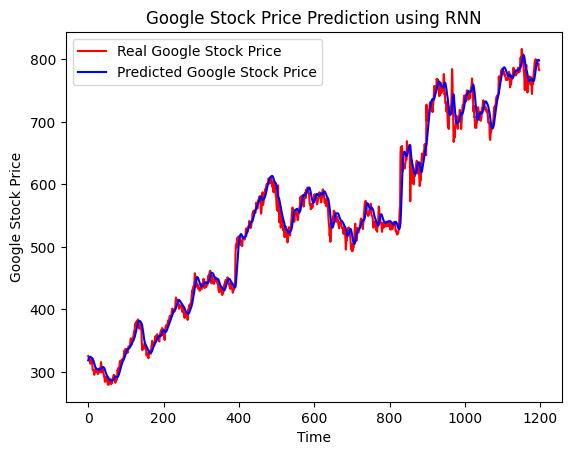

In [5]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load Dataset
dataset = pd.read_csv(r"C:\\Users\HP\\Downloads\\Google_Stock_Price_Train.csv")

# Take Open Price Column
training_set = dataset.iloc[:, 1:2].values

# Feature Scaling
scaler = MinMaxScaler(feature_range=(0,1))
training_set_scaled = scaler.fit_transform(training_set)

# Create Data in Time Series Format
X_train = []
y_train = []

# Using previous 60 days to predict next day
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

# Convert to Numpy Arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

# Reshape Data for RNN
X_train = np.reshape(X_train,
                     (X_train.shape[0],
                      X_train.shape[1],
                      1))

print("X_train Shape:", X_train.shape)

# Build RNN Model
model = Sequential()

# First LSTM Layer
model.add(LSTM(units=50,
               return_sequences=True,
               input_shape=(X_train.shape[1], 1)))

# Second LSTM Layer
model.add(LSTM(units=50))

# Output Layer
model.add(Dense(units=1))

# Compile Model
model.compile(optimizer='adam',
              loss='mean_squared_error')

# Train Model
model.fit(X_train,
          y_train,
          epochs=20,
          batch_size=32)

# Predict Future Values on Training Data
predicted_stock_price = model.predict(X_train)

# Convert Back to Original Values
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# Print Real and Predicted Prices
real_prices = training_set[60:]

print("\nReal Price\tPredicted Price")
print("-----------------------------------")

for i in range(len(predicted_stock_price)):
    print(f"{real_prices[i][0]:.2f}\t\t{predicted_stock_price[i][0]:.2f}")

# Plot Results
plt.plot(training_set[60:], color='red',
         label='Real Google Stock Price')

plt.plot(predicted_stock_price,
         color='blue',
         label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction using RNN')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()

plt.show()